<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [17]:
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read World bank CSV

In [4]:
df = pd.read_csv("WorldBank.csv")
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072e+00,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050e+00,1.012461e+01,9.451370e+00,1.052948e+01,1.089112e+01,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,1.708001e+01,1.519791e+01,1.686304e+01,2.200813e+01,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261e+00,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,India,IND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.002065e+00,1.312934e+00,1.516276e+00,1.695659e+00,2.092116e+00,1.937363e+00,1.506588e+00,1.552336e+00,1.760283e+00,NaN
1436,India,IND,"Net capital account (BoP, current US$)",BN.TRF.KOGT.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.791581e+07,-5.972328e+08,9.618297e+08,-7.433364e+07,3.706943e+07,1.368359e+08,3.731153e+07,-1.231007e+08,-1.155591e+09,NaN
1437,India,IND,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.761773e+01,1.544257e+01,1.475397e+01,1.799216e+01,1.795378e+01,1.707263e+01,1.686302e+01,1.716750e+01,1.755462e+01,NaN
1438,India,IND,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,8.737650e+07,8.725755e+07,9.037301e+07,9.370600e+07,7.969950e+07,...,2.878600e+08,2.932900e+08,2.949095e+08,2.960100e+08,2.843330e+08,2.978500e+08,3.136100e+08,NaN,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [23]:
data = df[df['Indicator Name']=='Population ages 15-64 (% of total population)']
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [35]:
x = np.arange(1960,2020).reshape(-1,1)

In [37]:
y = data.values[0][4:-1].reshape(-1,1)
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

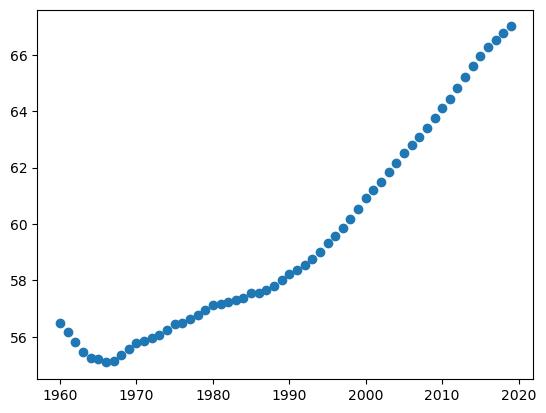

In [43]:
plt.scatter(x,y)

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [45]:
from sklearn.preprocessing import StandardScaler

In [53]:
sc_x = StandardScaler()
sc_y = StandardScaler()

x_scaled = sc_x.fit_transform(x)
y_scaled = sc_y.fit_transform(y)

print('Scaling Complete.')

Scaling Complete.


# Fitting SVR on Linear Kernel on dataset

In [122]:
from sklearn.svm import SVR

In [172]:
svr_lin = SVR(kernel='linear')

In [174]:
svr_lin.fit(x_scaled,y_scaled.ravel())

SVR(kernel='linear')

# Predict Values using Model

In [177]:
# use inverse_transform

In [179]:
y_pred  = svr_lin.predict(x_scaled).reshape(-1,1)
y_pred

array([[-1.67183895],
       [-1.6161734 ],
       [-1.56050784],
       [-1.50484228],
       [-1.44917672],
       [-1.39351116],
       [-1.33784561],
       [-1.28218005],
       [-1.22651449],
       [-1.17084893],
       [-1.11518337],
       [-1.05951782],
       [-1.00385226],
       [-0.9481867 ],
       [-0.89252114],
       [-0.83685558],
       [-0.78119003],
       [-0.72552447],
       [-0.66985891],
       [-0.61419335],
       [-0.55852779],
       [-0.50286224],
       [-0.44719668],
       [-0.39153112],
       [-0.33586556],
       [-0.2802    ],
       [-0.22453444],
       [-0.16886889],
       [-0.11320333],
       [-0.05753777],
       [-0.00187221],
       [ 0.05379335],
       [ 0.1094589 ],
       [ 0.16512446],
       [ 0.22079002],
       [ 0.27645558],
       [ 0.33212114],
       [ 0.38778669],
       [ 0.44345225],
       [ 0.49911781],
       [ 0.55478337],
       [ 0.61044893],
       [ 0.66611448],
       [ 0.72178004],
       [ 0.7774456 ],
       [ 0

In [185]:
y_lin_fit = sc_y.inverse_transform(y_pred)

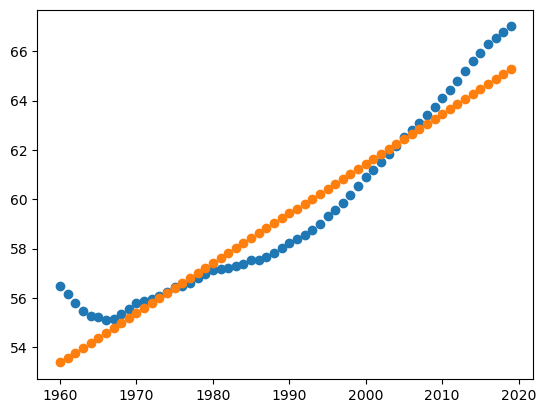

In [187]:
plt.scatter(x,y)
plt.scatter(x,y_lin_fit)

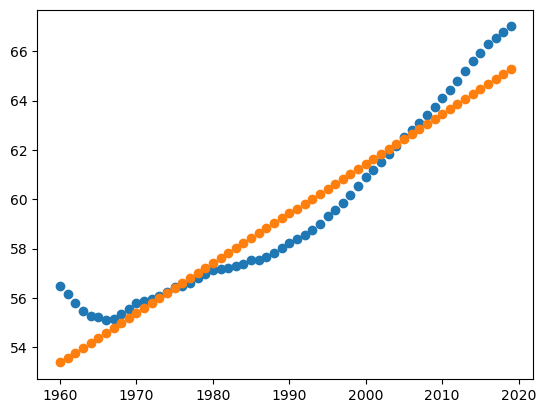

In [137]:
svr_poly = SVR(kernel='poly' , degree=3)
svr_poly.fit(x_scaled,y_scaled.ravel())

SVR(kernel='poly')

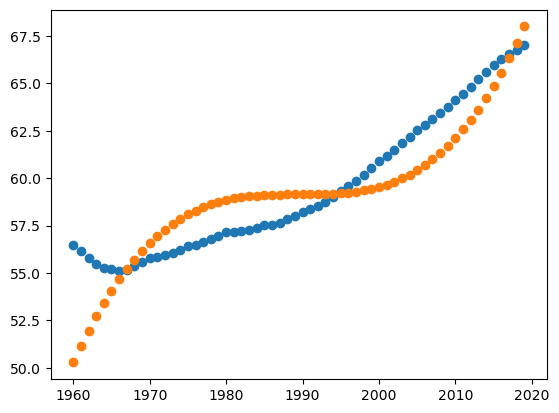

In [161]:
y_poly_pred  = svr_poly.predict(x_scaled).reshape(-1,1)
y_poly_fit = sc_y.inverse_transform(y_poly_pred)
plt.scatter(x,y)
plt.scatter(x,y_poly_fit)

# Predict the X_scaled using 3 Kernel

In [ ]:
# above Steps Only - Kernel Change

In [153]:
svr_rbf = SVR(kernel='rbf' , degree=3,gamma=)
svr_rbf.fit(x_scaled,y_scaled.ravel())

SVR()

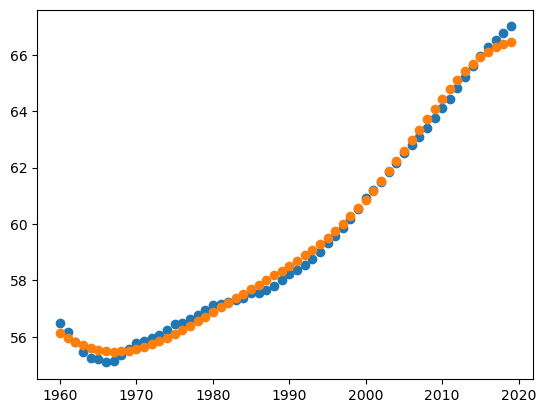

In [157]:
y_rbf_pred  = svr_rbf.predict(x_scaled).reshape(-1,1)
y_rbf_fit = sc_y.inverse_transform(y_rbf_pred)
plt.scatter(x,y)
plt.scatter(x,y_rbf_fit)

# Visualising the  results

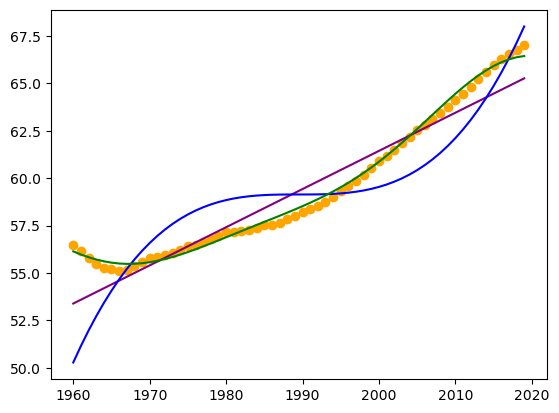

In [195]:
plt.scatter(x,y,color='orange')
plt.plot(x,y_lin_fit,color='purple')
plt.plot(x,y_poly_fit,color='blue')
plt.plot(x,y_rbf_fit,color='green')

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

# Extra
# Till now, we have not divided the dataset into training and testing sets.
# Please split the data into training and testing datasets and calculate the Residual Sum of Squares (RSS) for the model.